<a href="https://colab.research.google.com/github/hongxu-yn/Drought-monitoring-and-assessment/blob/main/src/%E7%A0%94%E7%A9%B6%E5%8C%BA%E6%A6%82%E5%86%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 初始化

In [2]:
from google.colab import drive
drive.mount('/content/drive')
png_dir="/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/结果与分析"
!apt-get update -qq
!apt-get install -y fonts-freefont-ttf
!pip install cartopy
!pip install adjustText
!pip install netcdf4 h5netcdf scipy
!apt-get install -y ttf-mscorefonts-installer

Mounted at /content/drive
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80). - connect (111: Connection refused)
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-freefont-ttf
0 upgraded, 1 newly installed, 0 to remove and 69 not upgraded.
Need to get 2,388 kB of archives.
After this operation, 6,653 kB of additional disk space will be used.
Get:1 http://ar

In [6]:
import geopandas as gpd
import os
import zipfile

# 1. 读取 GeoJSON 文件
input_file = '/content/drive/MyDrive/gis/china/中国_省.geojson'
gdf = gpd.read_file(input_file)

# 2. 核心修正：只筛选出 'Polygon' 和 'MultiPolygon'
# 过滤掉 LineString, MultiLineString 和 Point
gdf_polygons = gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

print(f"原始记录: {len(gdf)} 条")
print(f"过滤后（面状记录）: {len(gdf_polygons)} 条")
print(f"被剔除的非面状记录: {len(gdf) - len(gdf_polygons)} 条")

# 3. 导出为 SHP
output_dir = "./china_county_shp"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 建议使用 'GBK' 编码，因为国内很多 GIS 软件（如 ArcGIS）默认对 UTF-8 的 SHP 支持不佳
gdf_polygons.to_file(os.path.join(output_dir, "China_Counties.shp"),
                     driver='ESRI Shapefile',
                     encoding='utf-8')

print("✅ 转换完成！非面状要素已被自动剔除，SHP 已生成。")

原始记录: 42 条
过滤后（面状记录）: 34 条
被剔除的非面状记录: 8 条
✅ 转换完成！非面状要素已被自动剔除，SHP 已生成。


成功读取: china_province.shp，编码: GB18030
成功读取: 中国范围.shp，编码: GB18030
成功读取: boua_d.shp，编码: GB18030
成功读取: boua_s.shp，编码: GB18030
左图使用已有的 gdf_polygons。


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from GB18030 to UTF-8.  This warning will not be emitted anymore
  return ogr_read(


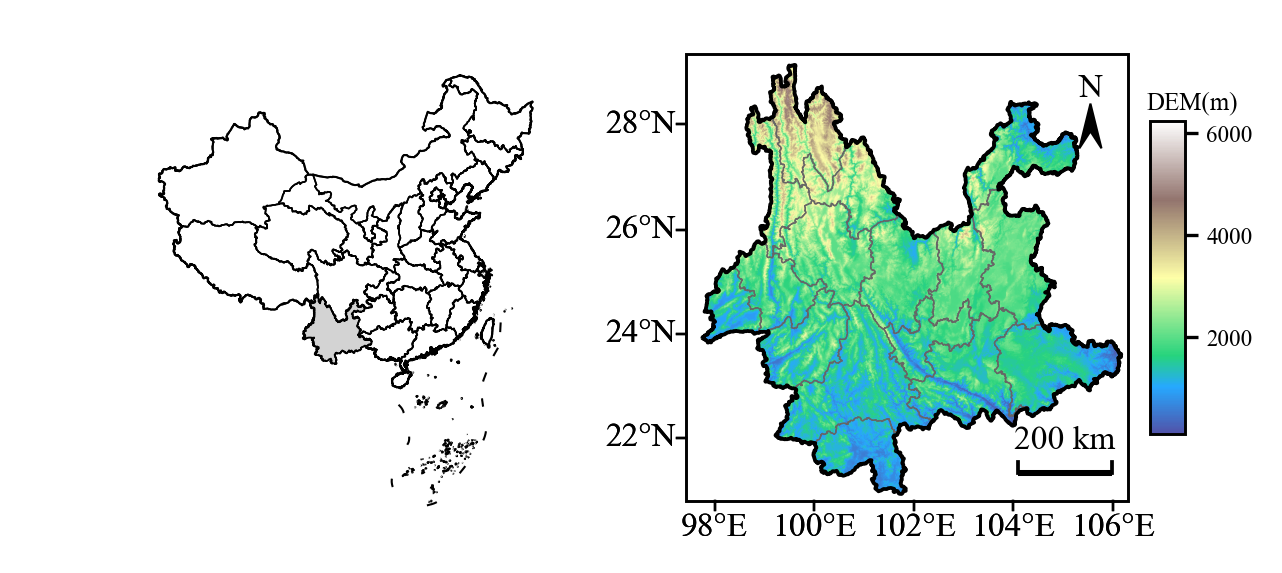

PNG saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_SCI_Albers_cn_outline.png
PDF saved to: /content/drive/MyDrive/Drought-monitoring-and-assessment/figures/Fig1_study_area_SCI_Albers_cn_outline.pdf


In [130]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import geopandas as gpd
from pathlib import Path
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.mask import mask

project_dir = Path("/content/drive/MyDrive/Drought-monitoring-and-assessment")
fig_dir = project_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# =====================================================
# 字体设置
# =====================================================
font_dir = Path("/content/drive/MyDrive/fonts")
font_en_path = font_dir / "TimesNewRoman.ttf"
font_zh_path = font_dir / "SimSun.ttf"

if not font_en_path.exists():
    raise FileNotFoundError(f"未找到英文字体: {font_en_path}")
if not font_zh_path.exists():
    raise FileNotFoundError(f"未找到中文字体: {font_zh_path}")

fm.fontManager.addfont(str(font_en_path))
fm.fontManager.addfont(str(font_zh_path))

font_en = fm.FontProperties(fname=str(font_en_path))
font_zh = fm.FontProperties(fname=str(font_zh_path))
font_en_name = font_en.get_name()

mpl.rcParams.update({
    "font.family": font_en_name,
    "font.serif": [font_en_name],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.7,
    "savefig.facecolor": "white",
    "figure.facecolor": "white"
})


def read_shp_safely(shp_path, target_crs="EPSG:4326", default_crs="EPSG:4326"):
    """
    因为我们之前已经修复了 .prj 文件，现在可以用最稳健的方式读取。
    优先尝试 pyogrio 引擎读取，若失败则退回 fiona。
    """
    shp_path = Path(shp_path)

    if not shp_path.exists():
        raise FileNotFoundError(f"未找到矢量文件: {shp_path}")

    encodings = ["GB18030", "GBK", "utf-8"]
    last_error = None

    for enc in encodings:
        try:
            try:
                # pyogrio 速度更快且处理编码更好
                gdf = gpd.read_file(shp_path, engine="pyogrio", encoding=enc)
            except Exception:
                # 退回默认引擎
                gdf = gpd.read_file(shp_path, encoding=enc)

            gdf = gdf[
                gdf.geometry.notna() & (~gdf.geometry.is_empty)
            ].copy()

            if gdf.crs is None:
                print(f"提示：{shp_path.name} 未检测到 CRS，已默认设置为 {default_crs}")
                gdf = gdf.set_crs(default_crs)

            gdf = gdf.to_crs(target_crs)

            print(f"成功读取: {shp_path.name}，编码: {enc}")
            return gdf

        except Exception as e:
            last_error = e

    raise RuntimeError(f"读取失败: {shp_path}\n最后一次错误为:\n{last_error}")

def projected_aspect(proj, extent):
    lon_min, lon_max, lat_min, lat_max = extent
    lons = np.array([lon_min, lon_max, lon_max, lon_min])
    lats = np.array([lat_min, lat_min, lat_max, lat_max])
    pts = proj.transform_points(pc, lons, lats)
    xs = pts[:, 0]
    ys = pts[:, 1]
    return (xs.max() - xs.min()) / (ys.max() - ys.min())

def set_map_frame(ax, linewidth=0.7):
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_color("black")

def add_panel_label(ax, label, title, fontsize=9.5):
    ax.text(
        0.018, 0.982,
        f"{label} {title}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontproperties=font_en, fontsize=fontsize, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=1.2),
        zorder=100
    )

def add_manual_lonlat_ticks(ax, xticks, yticks, extent_lonlat, labelsize=8, tick_frac=0.014, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58):
    proj = ax.projection
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xlen = x1 - x0
    ylen = y1 - y0

    tick_len_y = ylen * tick_frac
    tick_len_x = xlen * tick_frac
    lon_min, lon_max, lat_min, lat_max = extent_lonlat

    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    ref_lat = lat_min
    for lon in xticks:
        x_tick, _ = proj.transform_point(lon, ref_lat, pc)
        if x0 <= x_tick <= x1:
            # 【修改点】：y0 + tick_len_y 改为 y0 - tick_len_y，使刻度线向下（向外）延伸
            ax.plot([x_tick, x_tick], [y0, y0 - tick_len_y], color="black", linewidth=linewidth, clip_on=False, zorder=90)
            ax.text(x_tick, y0 - ylen * xpad_frac, f"{int(lon)}°E", ha="center", va="top", fontproperties=font_en, fontsize=labelsize, clip_on=False, zorder=91)

    ref_lon = lon_min
    for lat in yticks:
        _, y_tick = proj.transform_point(ref_lon, lat, pc)
        if y0 <= y_tick <= y1:
            # 【修改点】：x0 + tick_len_x 改为 x0 - tick_len_x，使刻度线向左（向外）延伸
            ax.plot([x0, x0 - tick_len_x], [y_tick, y_tick], color="black", linewidth=linewidth, clip_on=False, zorder=90)
            ax.text(x0 - xlen * ypad_frac, y_tick, f"{int(lat)}°N", ha="right", va="center", fontproperties=font_en, fontsize=labelsize, clip_on=False, zorder=91)

def add_north(ax, labelsize=8, loc_x=0.915, loc_y=0.962, width=0.045, height=0.075, pad=0.108):
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()
    xlen = maxx - minx
    ylen = maxy - miny

    left = [minx + xlen * (loc_x - width * 0.5), miny + ylen * (loc_y - pad)]
    right = [minx + xlen * (loc_x + width * 0.5), miny + ylen * (loc_y - pad)]
    top = [minx + xlen * loc_x, miny + ylen * (loc_y - pad + height)]
    center = [minx + xlen * loc_x, left[1] + (top[1] - left[1]) * 0.38]

    triangle = mpatches.Polygon([left, top, right, center], facecolor="black", edgecolor="black", linewidth=0.5, zorder=95)
    ax.add_patch(triangle)
    ax.text(x=minx + xlen * loc_x, y=miny + ylen * (loc_y - pad + height), s="N", fontsize=labelsize, fontproperties=font_en, ha="center", va="bottom", color="black", zorder=96)

def add_scalebar_albers(ax, length_km=200, location=(0.075, 0.075), linewidth=1.45, labelsize=8):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xlen = x1 - x0
    ylen = y1 - y0

    start_x = x0 + xlen * location[0]
    start_y = y0 + ylen * location[1]

    scale_len = length_km * 1000.0
    tick_h = ylen * 0.012

    ax.plot([start_x, start_x + scale_len], [start_y-tick_h, start_y-tick_h], color="black", linewidth=linewidth, solid_capstyle="butt", zorder=95)
    ax.plot([start_x, start_x], [start_y - tick_h, start_y + tick_h], color="black", linewidth=0.9, zorder=95)
    ax.plot([start_x + scale_len, start_x + scale_len], [start_y - tick_h, start_y + tick_h], color="black", linewidth=0.9, zorder=95)
    ax.text(start_x + scale_len / 2, start_y + tick_h * 2.3, f"{length_km} km", ha="center", va="bottom", fontsize=labelsize, fontproperties=font_en, color="black", zorder=96)

def plot_outline_mixed_geometry(gdf, ax, color="black", linewidth=0.6, zorder=10):
    geom_type = gdf.geometry.geom_type
    poly_gdf = gdf[geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    line_gdf = gdf[geom_type.isin(["LineString", "MultiLineString"])].copy()

    if not poly_gdf.empty:
        poly_gdf.boundary.plot(ax=ax, color=color, linewidth=linewidth, zorder=zorder)
    if not line_gdf.empty:
        line_gdf.plot(ax=ax, color=color, linewidth=linewidth, zorder=zorder)

# =====================================================
# 1. 路径设置 (✅ 更新：加入省界和市界)
# =====================================================
china_shp = "/content/drive/MyDrive/gis/china/china_province.shp"
cn_outline_shp = "/content/drive/MyDrive/gis/china/中国范围.shp"
yn_shp = "/content/drive/MyDrive/gis/boua_s.shp"    # 云南省界
yn_d_shp = "/content/drive/MyDrive/gis/boua_d.shp"  # 云南市界
dem_tif = "/content/drive/MyDrive/gis/dem_wgs84.tif"

out_png = fig_dir / "Fig1_study_area_SCI_Albers_cn_outline.png"
out_pdf = fig_dir / "Fig1_study_area_SCI_Albers_cn_outline.pdf"

china_gdf = read_shp_safely(china_shp)
cn_outline_gdf = read_shp_safely(cn_outline_shp)
yn_d_gdf = read_shp_safely(yn_d_shp)       # 省界
yn_outline = read_shp_safely(yn_shp)       # 省界

try:
    left_gdf = gdf_polygons.to_crs("EPSG:4326")
    left_gdf = left_gdf[
        left_gdf.geometry.notna() & (~left_gdf.geometry.is_empty)
    ].copy()
    left_gdf["geometry"] = left_gdf["geometry"].buffer(0)
    print("左图使用已有的 gdf_polygons。")
except NameError:
    left_gdf = china_gdf.copy()
    print("未检测到 gdf_polygons，左图使用 china_province.shp。")

proj_albers = ccrs.AlbersEqualArea(
    central_longitude=105,
    central_latitude=35,
    standard_parallels=(25, 47)
)
pc = ccrs.PlateCarree()

albers_crs = (
    "+proj=aea +lat_0=35 +lon_0=105 "
    "+lat_1=25 +lat_2=47 "
    "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

left_gdf_albers = left_gdf.to_crs(albers_crs)
china_gdf_albers = china_gdf.to_crs(albers_crs)
cn_outline_albers = cn_outline_gdf.to_crs(albers_crs)

yn_gdf_albers = yn_gdf.to_crs(albers_crs)         # 投影后的省界
yn_d_gdf_albers = yn_d_gdf.to_crs(albers_crs)     # 投影后的市界
yn_outline_albers = yn_outline.to_crs(albers_crs) # 投影后的省外围轮廓


# =====================================================
# 6. 显示范围
# =====================================================
# 左图范围以“中国范围.shp”为准
cn_minx, cn_miny, cn_maxx, cn_maxy = cn_outline_gdf.total_bounds

china_buffer = 3
china_extent = [
    cn_minx - china_buffer, cn_maxx + china_buffer,
    cn_miny - china_buffer, cn_maxy + china_buffer
]

# 右图云南范围 (以省界 bbox 为准)
minx, miny, maxx, maxy = yn_outline.total_bounds
yn_buffer = 0.1
yn_extent = [
    minx - yn_buffer, maxx + yn_buffer,
    miny - yn_buffer, maxy + yn_buffer
]


china_aspect = projected_aspect(proj_albers, china_extent)
yn_aspect = projected_aspect(proj_albers, yn_extent)

fig = plt.figure(figsize=(4, 2.8),dpi=300, facecolor="white")
gs = GridSpec(
    1, 2, figure=fig,
    left=0.070, right=0.985, bottom=0.05, top=0.95,
    wspace=0.01, width_ratios=[china_aspect, yn_aspect]
)
ax1 = fig.add_subplot(gs[0, 0], projection=proj_albers)
ax2 = fig.add_subplot(gs[0, 1], projection=proj_albers)

ax1.set_extent(china_extent, crs=pc)
plot_outline_mixed_geometry(cn_outline_albers, ax=ax1, color="black", linewidth=0.50, zorder=7)
left_gdf_albers.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.4, zorder=2)

yn_outline_albers.plot(ax=ax1, facecolor="lightgray", edgecolor="black", linewidth=0.4, zorder=8)
ax1.set_extent(china_extent, crs=pc)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.set_xticks([])
ax1.set_yticks([])

fig.canvas.draw()

# =====================================================
# 8.2 右图：云南研究区
# =====================================================
# =====================================================
# 8.2 右图：云南研究区 (✅ 已更新：加入 DEM 图例)
# =====================================================
ax2.set_extent(yn_extent, crs=pc)

ax2.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#f7fbff", edgecolor="none", zorder=0)
ax2.add_feature(cfeature.LAND.with_scale("50m"), facecolor="white", edgecolor="none", zorder=1)

# 读取、按省界裁剪 DEM 并显示
with rasterio.open(dem_tif) as src:
    out_image, out_transform = mask(src, yn_gdf.geometry, crop=True, filled=False)
    dem_data = out_image[0]

    b = rasterio.transform.array_bounds(out_image.shape[1], out_image.shape[2], out_transform)
    dem_extent = [b[0], b[2], b[1], b[3]]

# 🟢 修改点 1：将 imshow 的结果赋值给 img 变量
img = ax2.imshow(
    dem_data,
    extent=dem_extent,
    transform=pc,
    cmap="terrain",
    origin="upper",
    zorder=1.5,
    alpha=0.85
)

# 绘制市级边界 (内部透明)
yn_d_gdf_albers.plot(
    ax=ax2,
    facecolor="none",
    edgecolor="#666666",
    linewidth=0.32,
    zorder=2
)

# 顶层：绘制省级大边界
yn_outline_albers.boundary.plot(
    ax=ax2,
    edgecolor="black",
    linewidth=0.9,
    zorder=5
)

ax2.set_extent(yn_extent, crs=pc)
set_map_frame(ax2, linewidth=0.70)

fig.canvas.draw()

add_manual_lonlat_ticks(
    ax=ax2,
    xticks=[98, 100, 102, 104, 106],
    yticks=[22, 24, 26, 28],
    extent_lonlat=yn_extent,
    labelsize=8, tick_frac=0.02, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58
)

# [x起点, y起点, 宽度, 高度] 是相对 ax2 的比例坐标 (0~1)
cax = ax2.inset_axes([1.05, 0.15, 0.08, 0.7])
cbar = plt.colorbar(img, cax=cax, orientation="vertical")

# 🟢 已更新：将图例标题修改为 "DEM(m)"
cbar.ax.set_title("DEM(m)", fontproperties=font_en, fontsize=6, pad=3,x=1.2,loc="center")
cbar.ax.tick_params(length=3, pad=2)
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(font_en)
    label.set_fontsize(5.5)

ax2.set_extent(yn_extent, crs=pc)
set_map_frame(ax2, linewidth=0.70)

add_manual_lonlat_ticks(
    ax=ax2,
    xticks=[98, 100, 102, 104, 106],
    yticks=[22, 24, 26, 28],
    extent_lonlat=yn_extent,
    labelsize=8, tick_frac=0.02, xpad_frac=0.026, ypad_frac=0.022, linewidth=0.58
)

add_north(ax2, labelsize=8, loc_x=0.915, loc_y=0.80, width=0.05, height=0.1, pad=0.01)
add_scalebar_albers(ax=ax2, length_km=200, location=(0.75, 0.075), linewidth=1.45, labelsize=8)

fig.canvas.draw()
# =====================================================
# 9. 保存
# =====================================================
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print(f"PNG saved to: {out_png}")
print(f"PDF saved to: {out_pdf}")

In [45]:
prj_path = "/content/drive/MyDrive/gis/china/中国范围.prj"

# 我把 "中国坐标系" 替换成了全英文的 "China_Albers"，其余参数一字不改
clean_wkt = 'PROJCS["China_Albers",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers"],PARAMETER["False_Easting",0.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",105.0],PARAMETER["Standard_Parallel_1",25.0],PARAMETER["Standard_Parallel_2",47.0],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]'

# 强制以标准 utf-8 编码覆盖写入源文件
with open(prj_path, 'w', encoding='utf-8') as f:
    f.write(clean_wkt)

print("🎉 完美修复！.prj 文件中的中文字符已清除。现在您可以放心地去运行您的制图主代码了！")

🎉 完美修复！.prj 文件中的中文字符已清除。现在您可以放心地去运行您的制图主代码了！


In [ ]:
import geopandas as gpd

# 1. 数据诊断：看看你的 'gb' 到底长什么样
sample_gb = gdf_polygons['gb'].iloc[0]
print(f"DEBUG: 'gb' 字段的原始类型是: {type(sample_gb)}")
print(f"DEBUG: 'gb' 字段的一个示例值: '{sample_gb}'")

# 2. 定义 53 个干热河谷县的核心关键词
# 尽量使用 2-3 个字的简称，以匹配“XX县”或“XX彝族自治县”
dhv_keywords = [
    "东川", "禄劝", "巧家", "永善", "鲁甸", "昭阳", "会泽", "新平", "元江", "华宁", "峨山", "易门",
    "昌宁", "龙陵", "隆阳", "施甸", "元谋", "双柏", "永仁", "武定", "大姚", "楚雄", "牟定", "禄丰",
    "弥勒", "建水", "元阳", "开远", "红河", "个旧", "石屏", "蒙自", "泸西", "丘北", "景东",
    "宾川", "鹤庆", "永平", "云龙", "南涧", "巍山", "漾濞", "永胜", "华坪", "宁蒗", "玉龙",
    "古城", "泸水", "兰坪", "永德", "凤庆", "镇康", "云县"
]

# 3. 核心修复步骤
# A. 先在全图范围内模糊匹配名称
candidates = gdf_polygons[gdf_polygons['name'].apply(lambda x: any(k in str(x) for k in dhv_keywords))].copy()

# B. 强制过滤出属于云南的记录 (GB代码 53 开头)
# 我们用更稳妥的方法：转成字符串后，只要包含 '53' 且位置在前两位
def is_yunnan(val):
    s = str(val).strip()
    return s.startswith('53') or s.startswith('530')

dhv_gdf = candidates[candidates['gb'].apply(is_yunnan)].copy()

# 4. 重点县标注 (30个面积大于30万亩的)
key_30 = ["东川", "禄劝", "巧家", "永善", "鲁甸", "会泽", "新平", "元江", "昌宁", "隆阳", "施甸",
          "元谋", "双柏", "永仁", "武定", "大姚", "建水", "元阳", "开远", "红河", "个旧", "景东",
          "宾川", "鹤庆", "云龙", "南涧", "永胜", "华坪", "宁蒗", "永德"]

dhv_gdf['is_key'] = dhv_gdf['name'].apply(lambda x: any(k in str(x) for k in key_30))

print(f"🎯 最终匹配结果: {len(dhv_gdf)} 个县 (目标值 53)。")
if len(dhv_gdf) > 0:
    print("匹配到的前 5 个县:", dhv_gdf['name'].head().tolist())

DEBUG: 'gb' 字段的原始类型是: <class 'str'>
DEBUG: 'gb' 字段的一个示例值: '156420704'
🎯 最终匹配结果: 0 个县 (目标值 53)。


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipython-input-1448/1652400927.py:41: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right', prop={'size': 12}, frameon=True, shadow=True)
/tmp/ipython-input-1448/1652400927.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', prop={'size': 12}, frameon=True, shadow=True)
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 20113 (\N{CJK UNIFIED IDEOGRAPH-4E91}) missing from font(s) DejaVu Sans.
  super()._update_title_

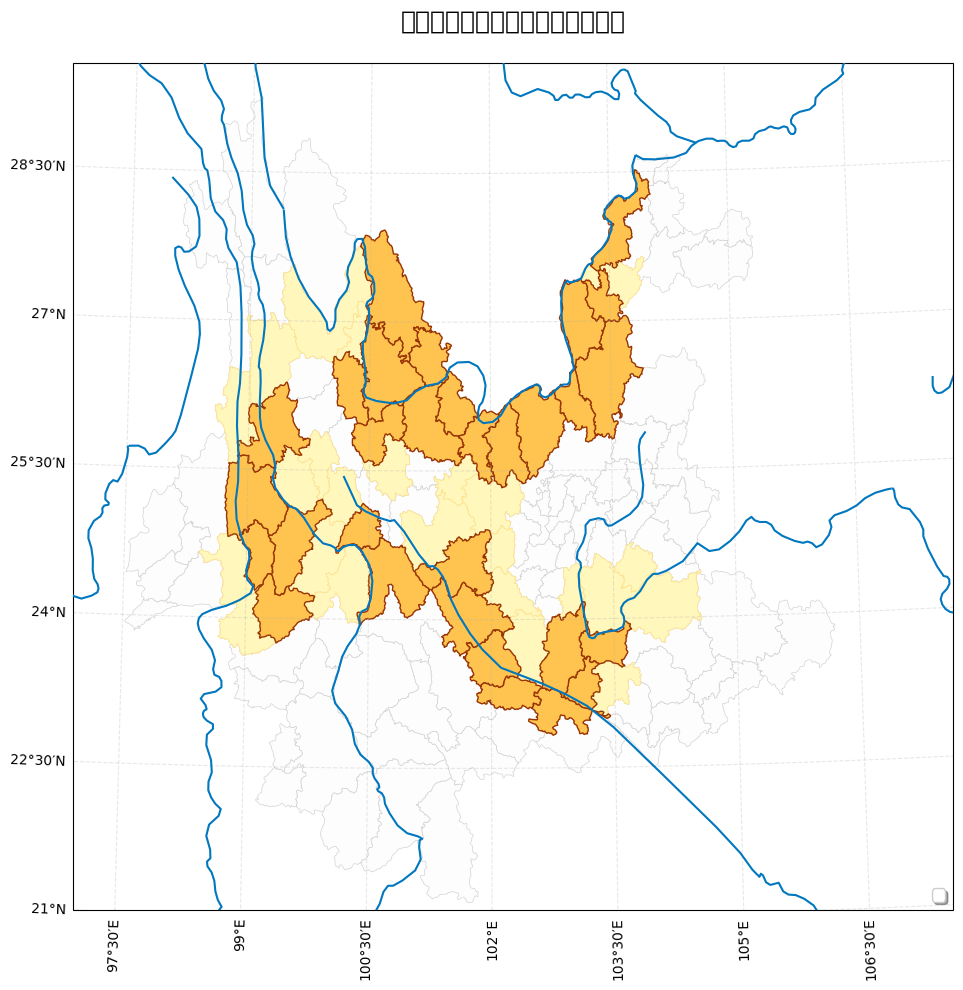

In [ ]:
import os
import glob
import xarray as xr
import pandas as pd
import warnings

# 1. 设置路径
data_path = '/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON/'
file_list = sorted(glob.glob(os.path.join(data_path, "*.nc")))

station_data = []

print(f"正在扫描 {len(file_list)} 个文件... \n")

# 2. 循环读取
for f in file_list:
    try:
        # 关键修正：decode_timedelta=False
        # 这会让 xarray 不去尝试解析 'day'/'hour' 变量，从而消灭警告
        with xr.open_dataset(f, decode_timedelta=False) as ds:

            # --- 提取基础信息 ---
            # 文件名与站点ID
            file_name = os.path.basename(f)
            site_id = file_name[:2] # 通常文件名前两个字母是站点缩写

            # 站点全名 (尝试多个常见属性字段)
            site_name = ds.attrs.get('long_name', ds.attrs.get('short_location', 'Unknown'))

            # --- 提取经纬度海拔 ---
            # 优先读全局属性，读不到则读变量
            lat = ds.attrs.get('station_latitude', ds.attrs.get('lat', None))
            lon = ds.attrs.get('station_longitude', ds.attrs.get('lon', None))
            alt = ds.attrs.get('station_altitude', ds.attrs.get('altitude', None))

            # 补救措施：如果属性是空的，尝试从数据变量里取第一个值
            if lat is None and 'lat' in ds: lat = ds['lat'].values.item(0) if ds['lat'].ndim > 0 else ds['lat'].values.item()
            if lon is None and 'lon' in ds: lon = ds['lon'].values.item(0) if ds['lon'].ndim > 0 else ds['lon'].values.item()
            if alt is None and 'altitude' in ds: alt = ds['altitude'].values.item(0) if ds['altitude'].ndim > 0 else ds['altitude'].values.item()

            # --- 提取时间范围 ---
            # 主时间变量 'time' 通常不需要 decode_timedelta 也能正常解析
            if 'time' in ds and len(ds['time']) > 0:
                # 转换为 pandas datetime 格式化
                t_start = pd.to_datetime(ds['time'].values[0])
                t_end = pd.to_datetime(ds['time'].values[-1])
                start_str = t_start.strftime('%Y-%m-%d')
                end_str = t_end.strftime('%Y-%m-%d')
                obs_count = ds.sizes['time']
            else:
                start_str, end_str, obs_count = 'N/A', 'N/A', 0

            # --- 存入列表 ---
            station_data.append({
                'ID': site_id,
                'Name': site_name,
                'Lat': round(float(lat), 2) if lat is not None else None,
                'Lon': round(float(lon), 2) if lon is not None else None,
                'Alt(km)': round(float(alt), 3) if alt is not None else None,
                'Start': start_str,
                'End': end_str,
                'Count': obs_count
            })

    except Exception as e:
        print(f"读取文件 {os.path.basename(f)} 失败: {e}")

# 3. 生成并展示表格
df = pd.DataFrame(station_data)

# 格式化显示
pd.set_option('display.max_rows', None)     # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.width', 1000)        # 防止换行

print("--- TCCON 站点汇总表 ---")
# 按照纬度从北到南排序，查看更直观
if not df.empty and 'Lat' in df.columns:
    df = df.sort_values(by='Lat', ascending=False).reset_index(drop=True)

print(df)
df

# 读取 TCCON

In [ ]:
import os
import glob
import xarray as xr
import pandas as pd
import warnings
tccon_file = '/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/TCCON_站点信息表.csv'
wdcgg_file = '/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/WDCGG_站点信息表_month.csv'

try:
    df_t = pd.read_csv(tccon_file)
    df_t.columns = df_t.columns.str.strip()
    col_map = {'Name': 'Name', 'name': 'Name', 'Lat': 'Lat', 'Lon': 'Lon'}
    df_t = df_t.rename(columns=lambda x: x.strip()).rename(columns=col_map)
    if 'Name' in df_t.columns:
        for i, r in df_t.iterrows():
            if 'hefei' in str(r['Name']).lower(): df_t.at[i, 'Lat'], df_t.at[i, 'Lon'] = 31.90, 117.17
            if 'xianghe' in str(r['Name']).lower(): df_t.at[i, 'Lat'], df_t.at[i, 'Lon'] = 39.75, 116.96
    df_t = df_t.dropna(subset=['Lat', 'Lon'])
except: df_t = pd.DataFrame([{'Name': 'Hefei', 'Lat': 31.90, 'Lon': 117.17}, {'Name': 'Xianghe', 'Lat': 39.75, 'Lon': 116.96}])

try:
    df_w = pd.read_csv(wdcgg_file)
    df_w.columns = df_w.columns.str.strip()
    lat_c = next(c for c in df_w.columns if 'lat' in c.lower())
    lon_c = next(c for c in df_w.columns if 'lon' in c.lower())
    type_c = next((c for c in df_w.columns if 'type' in c.lower()), 'Type')
    df_w = df_w.rename(columns={lat_c: 'Lat', lon_c: 'Lon', type_c: 'Type'})
    if 'Type' not in df_w.columns: df_w['Type'] = 'Surface'
    df_w['Type'] = df_w['Type'].astype(str).apply(lambda x: 'Tower' if 'tower' in x.lower() else 'Surface')
    df_w = df_w.dropna(subset=['Lat', 'Lon'])
except: df_w = pd.DataFrame()

In [ ]:
import os
save_dir = "/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

csv_path = os.path.join(save_dir, "TCCON_站点信息表.csv")
df.to_csv(csv_path, index=False, encoding='utf-8-sig') # utf-8-sig 确保 Excel 打开中文不乱码
print(f"✅ 站点信息表已保存至：\n1. {csv_path}")

✅ 站点信息表已保存至：
1. /content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/TCCON_站点信息表.csv


In [ ]:
csv_fn = "/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/hf_month_201511_202412.csv"
os.makedirs(os.path.dirname(csv_fn), exist_ok=True)

df_monthly.to_csv(csv_fn, index=False, encoding='utf-8')

print(f"✅ 日均值数据已成功保存至:\n{csv_fn}")
print(f"统计天数: {len(df_daily)} 天")

✅ 日均值数据已成功保存至:
/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/hf_month_201511_202412.csv
统计天数: 663 天


# 读取WDCGG


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_hf['date'] = df_hf['local_time'].dt.date
daily_mean = df_hf.groupby('date')['xco2'].transform('mean')



# --- 2. 季节划分与聚合 ---
def get_season(m):
    if m in [3, 4, 5]: return 'Spring'
    if m in [6, 7, 8]: return 'Summer'
    if m in [9, 10, 11]: return 'Autumn'
    return 'Winter'

df_hf['month'] = df_hf['local_time'].dt.month
df_hf['hour'] = df_hf['local_time'].dt.hour
df_hf['season'] = df_hf['month'].apply(get_season)

seasonal_hourly = df_hf.groupby(['season', 'hour'])['xco2'].agg(['mean', 'sem']).reset_index()
# --- 3. 绘制双子图 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

# (左图): 年振幅变化
# 注意：此处的 annual_amp 需沿用之前计算的结果
ax1.plot(annual_amp['year'], annual_amp['amplitude'], marker='o', color='#1f77b4', linewidth=2)
ax1.set_title('(a) Annual $XCO_2$ Amplitude', loc='left', fontweight='bold')
ax1.set_ylabel('Amplitude (ppm)')
ax1.grid(True, linestyle=':', alpha=0.6)

# (右图): 不同季节逐小时均值
# 使用 r'' 修复 SyntaxWarning
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']

for i, season in enumerate(seasons):
    data = seasonal_hourly[seasonal_hourly['season'] == season]
    data = data[data['hour'].between(7, 18)] # 聚焦白天观测时段

    ax2.plot(data['hour'], data['mean'], marker='o', markersize=4, label=season, color=colors[i])
    ax2.fill_between(data['hour'], data['mean'] - data['sem'], data['mean'] + data['sem'], color=colors[i], alpha=0.1)

ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title(r'(b) Seasonal Diurnal $\Delta XCO_2$ Cycles', loc='left', fontweight='bold')
ax2.set_xlabel('Local Time (Hour)')
ax2.set_ylabel(r'$\Delta XCO_2$ from Daily Mean (ppm)')
ax2.set_xticks(range(1, 24, 2))
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

# 研究区概况图

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
from shapely.ops import unary_union
import matplotlib.patheffects as PathEffects
import os
import pandas as pd
import matplotlib.font_manager as fm
import urllib.request

# ==========================================
# 0. 核心步骤：解决中文显示问题
# ==========================================
def configure_chinese_font():
    # 字体文件路径
    font_path = 'SimHei.ttf'
    # 如果当前目录下没有字体，则下载 (SimHei 是常用黑体)
    if not os.path.exists(font_path):
        print("⬇️ 正在下载中文字体 (SimHei)...")
        url = "https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf"
        urllib.request.urlretrieve(url, font_path)

    # 将字体添加到 Matplotlib 的字体管理器中
    fm.fontManager.addfont(font_path)

    # 设置全局字体为 SimHei
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['font.family'] = ['sans-serif']
    # 解决负号显示为方块的问题
    plt.rcParams['axes.unicode_minus'] = False

    print("✅ 中文字体配置完成。")

configure_chinese_font()
# 设置字号
plt.rcParams['font.size'] = 10

# ==========================================
# 1. 准备数据
# ==========================================
# 文件路径
tccon_file = '/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/TCCON_站点信息表.csv'
wdcgg_file = '/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/WDCGG_站点信息表_month.csv'

# 读取 WDCGG
try:
    df_wdcgg = pd.read_csv(wdcgg_file)
    df_wdcgg.columns = df_wdcgg.columns.str.strip()
    lat_col = next((c for c in df_wdcgg.columns if 'lat' in c.lower()), 'Latitude')
    lon_col = next((c for c in df_wdcgg.columns if 'lon' in c.lower()), 'Longitude')
    df_wdcgg = df_wdcgg.rename(columns={lat_col: 'Latitude', lon_col: 'Longitude'})
except:
    df_wdcgg = pd.DataFrame(columns=['Latitude', 'Longitude'])

# 手动添加/确保 香格里拉 存在
sl_data = {'Latitude': 27.83, 'Longitude': 99.73, 'Site_ID': 'Shangri-La'}
df_wdcgg = pd.concat([df_wdcgg, pd.DataFrame([sl_data])], ignore_index=True)

# 读取 TCCON
try:
    df_tccon = pd.read_csv(tccon_file)
    df_tccon.columns = df_tccon.columns.str.strip()
    lat_col_t = next((c for c in df_tccon.columns if 'lat' in c.lower()), 'Lat')
    lon_col_t = next((c for c in df_tccon.columns if 'lon' in c.lower()), 'Lon')
    df_tccon = df_tccon.rename(columns={lat_col_t: 'Lat', lon_col_t: 'Lon'})
except:
    df_tccon = pd.DataFrame(columns=['Lat', 'Lon'])

# 手动添加/确保 合肥 存在
hf_data = {'Lat': 31.90, 'Lon': 117.17, 'Name': 'Hefei'}
df_tccon = pd.concat([df_tccon, pd.DataFrame([hf_data])], ignore_index=True)

# ==========================================
# 2. 绘图初始化
# ==========================================
fig = plt.figure(figsize=(7, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree())
map_extent = [70, 135, -5, 55]
ax.set_extent(map_extent, crs=ccrs.PlateCarree())

# 底图
ax.add_feature(cfeature.OCEAN, facecolor='#E6F2FF')
ax.add_feature(cfeature.LAND, facecolor='#F5F3E7')
ax.add_feature(cfeature.NaturalEarthFeature('cultural','admin_0_countries','10m',
                                           facecolor='none', edgecolor='#333333', linewidth=0.6), zorder=2)

# 省界 (台湾外轮廓)
try:
    reader = shpreader.Reader(shpreader.natural_earth('10m','cultural','admin_1_states_provinces'))
    mainland = [r.geometry for r in reader.records() if r.attributes['admin'] == 'China']
    taiwan = [r.geometry for r in reader.records() if r.attributes['admin'] == 'Taiwan']
    if taiwan: mainland.append(unary_union(taiwan))
    ax.add_geometries(mainland, ccrs.PlateCarree(), facecolor='none', edgecolor='#888888', linewidth=0.4, linestyle='--', zorder=2)
except: pass

ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5, edgecolor='#444444')

# ==========================================
# 3. 绘制站点
# ==========================================
# 筛选范围
plot_wdcgg = df_wdcgg[(df_wdcgg['Longitude'] >= 70) & (df_wdcgg['Longitude'] <= 135)]
plot_tccon = df_tccon[(df_tccon['Lon'] >= 70) & (df_tccon['Lon'] <= 135)]

# 绘制点
ax.scatter(plot_wdcgg['Longitude'], plot_wdcgg['Latitude'],
           s=28, marker='o', color='#1f77b4', edgecolor='white',
           linewidth=0.4, transform=ccrs.PlateCarree(), zorder=5)

ax.scatter(plot_tccon['Lon'], plot_tccon['Lat'],
           s=75, marker='^', color='#d62728', edgecolor='white',
           linewidth=0.5, transform=ccrs.PlateCarree(), zorder=5)

# ==========================================
# 4. 装饰元素 (坐标/指北针/比例尺)
# ==========================================
# 坐标轴
ax.set_xticks(np.arange(80, 140, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(15, 60, 15), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(direction='out', length=3, width=0.5, labelsize=9)

# 指北针
ax.annotate('', xy=(0.06, 0.92), xytext=(0.06, 0.85), xycoords='axes fraction',
    arrowprops=dict(facecolor='black', edgecolor='black', width=1.2, headwidth=8, headlength=10))
ax.text(0.06, 0.93, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=10, fontweight='bold')

# 比例尺
def add_scalebar(ax, length_km=1000):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    lat = y0 + (y1-y0)*0.01; lon = x0 + (x1-x0)*0.05
    km_per_deg = 111.32 * np.cos(np.deg2rad(lat))
    length_deg = length_km / km_per_deg
    bar_h = (y1-y0)*0.015
    ax.add_patch(Rectangle((lon, lat), length_deg/2, bar_h, fc='black', ec='black', transform=ccrs.PlateCarree(), zorder=20))
    ax.add_patch(Rectangle((lon+length_deg/2, lat), length_deg/2, bar_h, fc='white', ec='black', lw=0.8, transform=ccrs.PlateCarree(), zorder=20))
    ax.text(lon, lat+bar_h*1.5, '0', ha='center', va='bottom', fontsize=9, transform=ccrs.PlateCarree())
    ax.text(lon+length_deg, lat+bar_h*1.5, f'{length_km} km', ha='center', va='bottom', fontsize=9, transform=ccrs.PlateCarree())

add_scalebar(ax, 1000)

# ==========================================
# 5. 中文标注与图例 (核心修改)
# ==========================================

# A. 云南红框
yunnan_ext = [97.5, 106.2, 21.1, 29.3]
ax.add_patch(Rectangle((yunnan_ext[0], yunnan_ext[2]), yunnan_ext[1]-yunnan_ext[0], yunnan_ext[3]-yunnan_ext[2],
                       linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=10))

# B. 中文站点标注
pe = [PathEffects.withStroke(linewidth=2, foreground="white")]

# 香格里拉 (中文)
ax.text(99.73 + 0.8, 27.83, '香格里拉', transform=ccrs.PlateCarree(),
        fontsize=10, fontweight='bold', color='black', path_effects=pe,
        ha='left', va='center', zorder=20)

# 合肥 (中文)
ax.text(117.17 + 0.8, 31.90 - 0.5, '合肥', transform=ccrs.PlateCarree(),
        fontsize=10, fontweight='bold', color='black', path_effects=pe,
        ha='left', va='top', zorder=20)

# C. 中文图例
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='TCCON 站点',
           markerfacecolor='#d62728', markersize=10, markeredgecolor='white'),
    Line2D([0], [0], marker='o', color='w', label='WDCGG 站点',
           markerfacecolor='#1f77b4', markersize=8, markeredgecolor='white'),
    Line2D([0], [0], color='red', linewidth=2, label='云南研究区')
]

ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.045, 0.05),
    frameon=False,
    fontsize=10,
    borderaxespad=0,
    handletextpad=0.5,
    prop={'family': 'SimHei', 'size': 10} # 确保图例也使用中文字体
)

# 标题
# ax.set_title("CO$_2$ 观测站点空间分布", fontdict={'fontsize': 12, 'fontweight': 'bold'})

for s in ax.spines.values(): s.set_linewidth(0.5)

plt.tight_layout()

# 保存
png_dir = "results"
if not os.path.exists(png_dir): os.makedirs(png_dir)
png_fn = os.path.join(png_dir, "研究区概况.png")
plt.savefig(png_fn, dpi=600, bbox_inches='tight')
print(f"Map saved to: {png_fn}")
plt.show()

ModuleNotFoundError: No module named 'cartopy'

In [ ]:
import xarray as xr
import pandas as pd
import glob
import os
import numpy as np
import re

# ==========================================
# 1. 设置路径
# ==========================================
wdcgg_path = '/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly'
nc_files = sorted(glob.glob(os.path.join(wdcgg_path, "*.nc")))

all_site_data = []

print(f"🚀 正在分析 {len(nc_files)} 个站点的观测时序信息...\n")

# ==========================================
# 2. 定义辅助函数
# ==========================================
def parse_time_info(ds):
    """智能解析时间信息，处理 'months since' 等复杂格式"""
    t_min, t_max, duration = "N/A", "N/A", 0
    if 'time' not in ds: return t_min, t_max, duration

    try:
        # 情况 A: 自动解码成功
        if np.issubdtype(ds['time'].dtype, np.datetime64) or isinstance(ds['time'].values[0], (pd.Timestamp, np.datetime64)):
            t_vals = ds['time'].values
            t_min = pd.to_datetime(t_vals.min())
            t_max = pd.to_datetime(t_vals.max())

        # 情况 B: 手动解析 'months since'
        else:
            units = ds['time'].attrs.get('units', '')
            raw_vals = ds['time'].values

            if 'months since' in units:
                date_str = re.search(r'\d{4}-\d{1,2}-\d{1,2}', units).group()
                base_date = pd.to_datetime(date_str)
                min_offset = int(np.nanmin(raw_vals))
                max_offset = int(np.nanmax(raw_vals))
                t_min = base_date + pd.DateOffset(months=min_offset)
                t_max = base_date + pd.DateOffset(months=max_offset)
            elif 'since' in units:
                t_vals = xr.decode_cf(ds, use_cftime=False).time.values
                t_min = pd.to_datetime(t_vals.min())
                t_max = pd.to_datetime(t_vals.max())

    except Exception as e: pass

    if isinstance(t_min, pd.Timestamp) and isinstance(t_max, pd.Timestamp):
        duration = (t_max - t_min).days
        t_min_str = t_min.strftime('%Y-%m-%d')
        t_max_str = t_max.strftime('%Y-%m-%d')
    else:
        t_min_str, t_max_str, duration = "N/A", "N/A", 0

    return t_min_str, t_max_str, duration

def get_site_type(filename):
    """从文件名解析站点类型"""
    # 常见文件名格式: co2_amt6050_tower-insitu_11_9999-9999_monthly.nc
    # 提取第3部分通常是类型
    parts = filename.split('_')
    if len(parts) > 2:
        return parts[2]  # 返回如 'tower-insitu', 'surface-flask'
    return 'Unknown'

# ==========================================
# 3. 主循环
# ==========================================
for fn in nc_files:
    base_name = os.path.basename(fn)
    try:
        # 尝试读取
        try:
            ds = xr.open_dataset(fn, engine='scipy')
        except ValueError:
            ds = xr.open_dataset(fn, engine='scipy', decode_times=False)

        with ds:
            # 1. 提取时间
            t_min, t_max, duration_days = parse_time_info(ds)

            # 2. 提取站点 ID 和 类型
            site_id = ds.attrs.get('station_code') or base_name.split('_')[1][:3].upper()
            site_type = get_site_type(base_name)  # <--- 新增类型提取

            # 3. 提取坐标
            def get_coord(keys):
                for k in keys:
                    if k in ds.coords or k in ds.data_vars:
                        v = ds[k].values
                        return float(v.item() if np.size(v) == 1 else v[0])
                    if k in ds.attrs: return float(ds.attrs[k])
                return np.nan

            lat = get_coord(['station_latitude', 'latitude', 'lat'])
            lon = get_coord(['station_longitude', 'longitude', 'lon'])
            alt = get_coord(['elevation', 'altitude', 'station_altitude', 'alt'])

            # 4. 存入数据
            all_site_data.append({
                "Site_ID": site_id,
                "Type": site_type,  # <--- 新增列
                "Start_Time": t_min,
                "End_Time": t_max,
                "Duration_Days": duration_days,
                "Latitude": lat,
                "Longitude": lon,
                "Altitude": alt,
                "File_Name": base_name
            })

    except Exception as e:
        print(f"❌ 严重错误 [{base_name}]: {e}")

# ==========================================
# 4. 结果展示与统计
# ==========================================
df_wdcgg_summary = pd.DataFrame(all_site_data)
if not df_wdcgg_summary.empty:
    df_wdcgg_summary = df_wdcgg_summary.sort_values('Duration_Days', ascending=False).reset_index(drop=True)

    print("\n" + "="*70)
    print(f"✅ 成功提取 {len(df_wdcgg_summary)} 个站点信息")
    print("="*70)

    # 打印类型统计
    print("\n📊 站点类型统计 (Site Type Distribution):")
    print(df_wdcgg_summary['Type'].value_counts())
    print("-" * 30)

    # 显示带类型的前几行
    display(df_wdcgg_summary[['Site_ID', 'Type', 'Start_Time', 'End_Time', 'Duration_Days', 'Latitude', 'Longitude']].head(10))

    # 保存结果
    save_path = '/content/drive/MyDrive/WDCGG_Monthly_Summary_With_Types.csv'
    df_wdcgg_summary.to_csv(save_path, index=False)
    print(f"\n💾 结果已保存至: {save_path}")

else:
    print("⚠️ 未提取到数据。")

🚀 正在分析 370 个站点的观测时序信息...


✅ 成功提取 370 个站点信息

📊 站点类型统计 (Site Type Distribution):
Type
tower-insitu      134
surface-insitu    117
surface-flask      96
ship-flask         22
surface-remote      1
Name: count, dtype: int64
------------------------------


,Site_ID,Type,Start_Time,End_Time,Duration_Days,Latitude,Longitude
0,NWR,surface-flask,1968-01-01,2024-12-01,20789,40.049999,-105.589996
1,MLO,surface-flask,1969-08-01,2024-12-01,20211,19.536230,-155.576157
2,SSL,tower-insitu,1972-01-01,2025-10-01,19632,47.900002,7.916667
3,BRW,surface-flask,1971-05-01,2024-12-01,19573,71.323013,-156.611465
4,KEY,surface-flask,1972-12-01,2024-12-01,18993,25.666666,-80.199997
5,BRW,surface-insitu,1973-08-01,2024-12-01,18750,71.322998,-156.610992
6,SMO,surface-flask,1973-08-01,2024-12-01,18750,-14.247475,-170.564514
7,MLO,surface-insitu,1974-01-01,2024-12-01,18597,19.535999,-155.576004
8,SSL,surface-insitu,1972-01-01,2022-12-01,18597,-999.999023,-9.000000
9,SPO,surface-insitu,1975-01-01,2024-12-01,18232,-89.980003,-24.799999



💾 结果已保存至: /content/drive/MyDrive/WDCGG_Monthly_Summary_With_Types.csv


In [ ]:
save_dir = "/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

csv_path = os.path.join(save_dir, "WDCGG_站点信息表_month.csv")
df_wdcgg_summary.to_csv(csv_path, index=False, encoding='utf-8-sig')

#/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/TCCON_站点信息表.csv
#/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/WDCGG_站点信息表.csv

In [ ]:
import xarray as xr
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.patheffects as patheffects

# 尝试导入 adjustText 用于标签自动避让
try:
    from adjustText import adjust_text
    ADJUST_TEXT_AVAILABLE = True
except ImportError:
    ADJUST_TEXT_AVAILABLE = False

# ==========================================
# 1. 批量解析 WDCGG 站点信息 (修复经度缺失问题)
# ==========================================
wdcgg_path = '/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/hourly'
nc_files = sorted(glob.glob(os.path.join(wdcgg_path, "*.nc")))
all_site_data = []

print(f"🚀 正在分析 {len(nc_files)} 个站点的元数据...")

for fn in nc_files:
    base_name = os.path.basename(fn)
    try:
        with xr.open_dataset(fn, engine='scipy', mmap=False) as ds:
            # 提取时间范围
            if 'time' in ds:
                t_min = pd.to_datetime(ds['time'].values.min())
                t_max = pd.to_datetime(ds['time'].values.max())
                duration = (t_max - t_min).days
            else:
                t_min = t_max = duration = "N/A"

            # 提取站点 ID
            site_id = ds.attrs.get('station_code') or base_name.split('_')[1][:3].upper()

            # 坐标提取辅助函数 (兼容各种变量名)
            def get_coord(keys):
                for k in keys:
                    if k in ds.coords or k in ds.data_vars:
                        v = ds[k].values
                        return float(v.item() if np.size(v) == 1 else v[0])
                    if k in ds.attrs: return float(ds.attrs[k])
                return np.nan

            lat = get_coord(['station_latitude', 'latitude', 'lat'])
            lon = get_coord(['station_longitude', 'longitude', 'lon'])
            alt = get_coord(['elevation', 'altitude', 'station_altitude', 'alt'])

            all_site_data.append({
                "Site_ID": site_id,
                "Start_Time": t_min.strftime('%Y-%m-%d') if isinstance(t_min, pd.Timestamp) else "N/A",
                "End_Time": t_max.strftime('%Y-%m-%d') if isinstance(t_max, pd.Timestamp) else "N/A",
                "Duration_Days": duration,
                "Latitude": lat,
                "Longitude": lon,
                "Altitude": alt,
                "File_Name": base_name
            })
    except Exception:
        continue

df_wdcgg_summary = pd.DataFrame(all_site_data).dropna(subset=['Longitude', 'Latitude'])
import os
save_dir = "/content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

csv_path = os.path.join(save_dir, "WDCGG_站点信息表_hourly.csv")
df_wdcgg_summary.to_csv(csv_path, index=False, encoding='utf-8-sig') # utf-8-sig 确保 Excel 打开中文不乱码
print(f"✅ 站点信息表已保存至：\n1. {csv_path}")

🚀 正在分析 286 个站点的元数据...
✅ 站点信息表已保存至：
1. /content/drive/MyDrive/xco2_datasets_conduct/project_01_oco2_dataset/step04_不确定性分析/WDCGG_站点信息表_hourly.csv
